<a href="https://colab.research.google.com/github/arturs-berzins/relu_edge_subdivision/blob/logml25/testbed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os

repo_url = "https://github.com/arturs-berzins/relu_edge_subdivision.git"
repo_dir = "relu_edge_subdivision"

if not os.path.exists(repo_dir):
    !git clone {repo_url}

%cd {repo_dir}

/content/relu_edge_subdivision/relu_edge_subdivision


In [2]:
import torch
torch.backends.cuda.matmul.allow_tf32 = False ## NOTE: important for consistency between cpu and cuda https://github.com/pytorch/pytorch/issues/77397
from NN import Net, NetBunny
from edge_subdivision import get_e_sv, lin_interp, get_unit_hypercube
from edge_subdivision import skeletal_subdivision
from time import time
import numpy as np

In [3]:
def get_intersecting_via_perturb(em_sv, d):
    '''
    Find intersecting edges (face, hyperplane intersections).
    Take all splitting edges. For each splitting edge find all incident faces by perturbing the sign-vector.
    This means taking one zero at a time and setting it to + or -. Since an edge has (d-1) zeros,
    this gives 2*(d-1) faces incident to each edge. Now we find the unique faces and the two edges
    that point to it. This is the only expensive step.
    Memory is O(e*2*(d-1)) where e is the nof split edges. Much better than O(n^2) when doing pairwise adjacency check.
    Output:
    novel_idxs_of_adj_edges is shape [#nof splitting edges, 2].
    novel_idxs_of_adj_edges[e] gives two indices i,j.
    This are the indices of edges in the _splitting_ edge array i.e. _masked_ edge array.
    E.g. e_tb[:,split_edge_mask][i] is the tb of the first edge.
    Convert to index in the full edge array via split_edge_mask.nonzero()[:,0][i]
    '''
    ## TODO: constants
    device = em_sv.device
    ## Range to adress (2)*(d-1) faces incident to edges
    rnge_dim = torch.arange(d-1, dtype=torch.int64, device=device)

    ## No splitting edges, return an empty pair
    if len(em_sv)==0: return torch.empty(0,2, dtype=int, device=device)

    ### Perturb edge sign-vectors to find faces ###

    ## Repeat each edge d-1 times for each zero and 2 times for +- which it can become.
    incident_faces_sv = em_sv[None,...].repeat(2,d-1,1,1)
    ## Find the locations of the zeros, which we will change to +-
    zero_idxs = (em_sv==0).nonzero()
    ## Create a tuple of indices for advanced indexing (analogous to what nonzero would return):
    ## 1st adresses all d-1 zeros w/ range
    ## 2nd adresses row locations of zeros (as in over perturbed edges)
    ## 3rd adresses col locations of zeros (as in over constraints)
    # assert len(zero_idxs)==len(em_sv)*(d-1), "The new hyperplane intersects an old vertex, the arrangement is not generic"
    idxs = (rnge_dim.repeat_interleave(len(em_sv)),) \
        + tuple(zero_idxs.reshape(len(em_sv), d-1, 2).permute(1,0,2).flatten(end_dim=1).T)

    ## Perturb to +-. TODO: perturb boundary cells only toward + to make b a bit smaller. Not sure if modulo will work though.
    incident_faces_sv[0][idxs] = 1
    incident_faces_sv[1][idxs] = -1

    ## Make a long list (a 2D tensor) of all face sign-vectors. Permute so we can use modulo in the end.
    b = incident_faces_sv.permute(1,0,2,3).flatten(end_dim=2)

    ### Find unique faces and their edges ###
    if device.type=='cuda':
        ## On cuda unique is faster: find unique faces and the indices telling where each face (perturbed edge) from b is in unique faces.
        _, inv = b.unique(dim=0, return_inverse=True)
        ## If we sort the inv, the perturbed edge pairs from b will be together in the sorted list.
        inv_sorted, inv_inds = inv.sort()
        ## Two same subsequent entries indicate a splitting face and a face-novel edge
        idxs_of_edge_pairs_in_inv = (~inv_sorted.diff().bool()).nonzero() ## Maybe bool mask?
        ## Now, indices of both perturbed edges sharing the face are offset by one. Convert these indices into b array indexing via inv_inds.
        ## Lastly, find indices of the edge pairs in the previous edge list by reversing the repeat with modulo.
        novel_idxs_of_adj_edges = inv_inds[torch.hstack([idxs_of_edge_pairs_in_inv, idxs_of_edge_pairs_in_inv+1])] %len(em_sv)
    else:
        ## On cpu lexsort is faster. Part of the reason is that pytorch cuda just does not have a native lexsort.
        ## The best available port is decent, but still worse than the native unique. This might be different with JAX.
        ## https://dagshub.com/safraeli/attention-learn-to-route/src/674e5760ce82183a56c94f453aaaf37fdf8e1953/utils/lexsort.py
        b_lex_idxs = torch.from_numpy(np.lexsort(b.numpy().T))
        b_lex = b[b_lex_idxs]
        idxs_of_edge_pairs_in_lex = torch.all(~b_lex.diff(dim=0).bool(), dim=1).nonzero()[:,0]
        novel_idxs_of_adj_edges = b_lex_idxs[torch.vstack([idxs_of_edge_pairs_in_lex, idxs_of_edge_pairs_in_lex+1]).T]%len(em_sv)

    ## em_sv[novel_idxs_of_adj_edges] are the sign-vectors of pairs of adjacent edges.
    ## They will have a single common 0 entry and D different entries where one is 0 at he other is +-.
    ## All other entries are identical +-.
    # print(em_sv[novel_idxs_of_adj_edges])
    return novel_idxs_of_adj_edges ## These indices are for the masked edge array of splitting edges

def skeletal_subdivision(f, bbox=(-1,1), device=None, verbose=True, plot=False, prune=False, return_intermediate=False, return_memory=False, allow_non_generic=True):
    '''
    Skeletal sub-division: sequential evaluation of vertices with the NN.
    '''
    # t0 = time()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device=='cuda' and return_memory: torch.cuda.reset_peak_memory_stats()

    ## Move the NN to the device
    f.to(device)

    ## Dimension of input
    d = f.ks[0]

    ## Hypercube
    vs_bits, edges = get_unit_hypercube(d)
    vs_bits = vs_bits.to(device)
    edges = edges.to(device)

    ## Vertex coordinates by transforming unit hypercube vertices
    vs = (vs_bits*(bbox[1]-bbox[0]) + bbox[0]).float() ## NOTE: here we can easily use different ranges for each dimension

    ## Vertex sign-vectors
    v_sv = torch.hstack([vs_bits, ~vs_bits]).to(dtype=torch.int8)
    del vs_bits

    ## Edge sign-vectors: if either vertex is +, the edge is +. This behaviour can be compactly computed using the sum
    e_sv = v_sv[edges].sum(1, dtype=torch.int8).sign()

    ## Bounding box constraints
    B = 2*d

    if return_intermediate:
        intermediates = {}

    # N=0
    v_mask = None
    t0 = time()
    lv = 0
    vals_for_all_neurons = torch.empty(0, sum(f.ks[1:]), device=device)
    # vals_for_all_neurons = f.eval_block(vs, device=device)
    ## Go through layers
    for l in f.ls:
        K = sum(f.ks[1:l])
        ## Go through neurons
        for k in range(f.ks[l]):
            # N+=1

            ## (1) Evaluate vertices
            ## Get vertex signs wrt all future neurons
            vals_for_all_neurons = torch.vstack([vals_for_all_neurons, f.eval_block(vs[lv:], device=device)])

            if prune:
                ### An edge is prunable if both it's vertices have the same sign wrt all future constraints
                p_rest = f.eval_block(vs, device=device)[:,v_sv.shape[1]-B:] > 0
                prunable = torch.all(p_rest[edges[:,0]]==p_rest[edges[:,1]], 1)
                edges = edges[~prunable]
                # print(f'{(sum(prunable)/len(prunable)).item():.2f}')
                ## A vertex is prunable if it has no edges
                ## Challenge here is to update the connectivity in edges
                v_idxs = edges.unique() ## These are vertices with at least one edge TODO: long term this also needs hashing
                v_mask = torch.zeros(len(vs), dtype=bool, device=device)
                v_mask[v_idxs] = True
                new_to_old = v_mask.cumsum(0)-1
                # assert torch.all(vs[edges] == vs[v_mask][new_to_old[edges]]) ## check if the edges are updated correctly

                ## Prune edges
                edges = new_to_old[edges]

                ## Prune vertices
                vs = vs[v_mask]
                v_sv = v_sv[v_mask]
                vals_for_all_neurons = vals_for_all_neurons[v_mask]

            ## Get values w.r.t. this neuron
            vals = vals_for_all_neurons[:,K+k]
            if torch.any(vals==0): ## torch.abs(vals)<1e-8
                print(
                "Warning: a hyperplane intersects a vertex (up to numerical precision). The arrangement is not generic."
                "\n 0 will be treated as +. This may cause unexpected behaviour.")
                assert allow_non_generic, "If you want to allow non-generic arrangements, set allow_non_generic=True"

            ## Sign-vectors of old vertices wrt new hyperplane
            old_vert_new_sv = torch.sign(vals).to(dtype=torch.int8)[:,None]
            old_vert_new_sv[old_vert_new_sv==0] = 1 ## NOTE: do not allow non-generic
            """
            In a generic arrangement never should vals==0.
            To prevent the current implementation from breaking, treat 0 as a positive value here.
            Long term, we can extend the implementation to generic arrangements.
            Hint: we do not want to track infinitesimal edges, so handle the case where both vertices are 0.
            If we have a non-generic thing, then we will append a zero to a sign-vector which already has D zeros.
            """

            ## (2,3) Compare vertex pair signs
            vals_pairs = vals[edges]
            del vals
            ## Find splitting edges by looking at signs of their vertices
            splitting_edge_mask = vals_pairs.sign().prod(1)==-1
            # split_edge_mask = vals_pairs.sign().to(dtype=torch.int8).prod(1)==-1

            ## (4) Interpolate to find new vertices on splitting edges
            ## In linear inteprolation
            ## xs are the neuron values
            ## ys are the vertex coordinates
            novel_coords = lin_interp(
                vals_pairs[splitting_edge_mask,None,0],
                vals_pairs[splitting_edge_mask,None,1],
                vs[edges][splitting_edge_mask,0],
                vs[edges][splitting_edge_mask,1])
            # novel_coords = lin_interp(
            #     *vals_pairs[split_edge_mask].transpose(0,1)[...,None],
            #     *vs[edges[split_edge_mask]].transpose(0,1))
            del vals_pairs

            #### Subdivision & sign-vector constructions ####
            ## Simple in principle, a bit messy in implementation


            ### (5) Intersecting edges ### NOTE: LOGML25: edit this step
            em_sv = get_e_sv(v_sv, edges[splitting_edge_mask])
            novel_idxs_of_adj_edges = get_intersecting_via_perturb(em_sv, d) ## TODO: clean up documentation, rename
            ## The indices of old parent edges that host the two vertices of the splitting edge:
            ## split_edge_mask.nonzero()[:,0][novel_idxs_of_adj_edges]
            ## The coordinates of the new vertex pairs of the edge:
            ## novel_coords[novel_idxs_of_adj_edges]

            ### Alternative code here
            # new vertex locations (coordiantes)
            # vs_new = novel_coords
            # new vertex sign sequences (previous edge + 0 at the end)
            v_sv_new = torch.hstack([em_sv, torch.zeros(len(novel_coords),1, dtype=torch.int8, device=device)])
            # the result should agree with novel_idxs_of_adj_edges up to permutation
            ###

            ### UPDATE ###
            ### Verts ###
            ## Store the number of old vertices before we in-place modify vs
            lv = len(vs)
            vs = torch.vstack([vs, novel_coords])
            v_sv = torch.vstack([
                torch.hstack([v_sv, old_vert_new_sv]),
                torch.hstack([em_sv, torch.zeros(len(novel_coords),1, dtype=torch.int8, device=device)]),
                ])
            del novel_coords, em_sv, old_vert_new_sv

            ### Edges ###
            ## Connect one old to one new index
            edges = torch.vstack([
                ## non-splitting edges: take old
                edges[~splitting_edge_mask],
                ## split edges: connect one old and one new vertex. Since the new vertices are added in order to vs, just increment index.
                torch.stack([
                    edges[splitting_edge_mask].T.flatten(),
                    (lv + torch.arange(splitting_edge_mask.sum(), device=device)).repeat(2)]).T,
                ## intersecting edges
                novel_idxs_of_adj_edges + lv,
            ])
            del splitting_edge_mask, novel_idxs_of_adj_edges

            if plot: ## Plot intermediate steps here
                # plot_verts_and_edges(vs, edges, v_labels=get_labels(v_tb, count=1))
                # plot_verts_and_edges(vs, edges)
                # edge_type = [(~split_edge_mask).sum(), splitting_edge_mask.sum(), len(novel_idxs_of_adj_edges)]
                # edge_colors = 'k' if edge_type is None else ['k']*edge_type[0] + ['b']*edge_type[1] + ['g']*edge_type[2]
                # plot_verts_and_edges(vs, edges, edge_colors=edge_colors)
                pass

        if verbose:
            print(f"Layer {l}: identified {len(vs):>12,} vertices and {len(edges):>12,} edges in total of {(time()-t0):>8.3f}s")

        if return_intermediate:
            intermediates[l] = (vs.clone(), edges.clone(), v_sv.clone())

    if return_intermediate:
        return intermediates

    # if return_memory:
    #     memory_max_cpu = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss  ## in kilobytes https://linux.die.net/man/2/getrusage
    #     memory_max_gpu = torch.cuda.max_memory_allocated()      ## in bytes https://pytorch.org/docs/stable/generated/torch.cuda.max_memory_allocated.html
    #     ## Convert to gigabytes
    #     memory_max_cpu /= 1024*1024
    #     memory_max_gpu /= 1024*1024*1024
    #     return vs, edges, v_sv, memory_max_cpu, memory_max_gpu

    if prune:
        pass ## TODO: in the end, we might want to prune away anything that is not the iso-level

    ## You can always get edge sign-vectors like this:
    # e_sv = get_e_sv(v_sv, edges)
    return vs, edges, v_sv


Layer 1: identified           18 vertices and           33 edges in total of    0.004s
Layer 2: identified           26 vertices and           51 edges in total of    0.013s


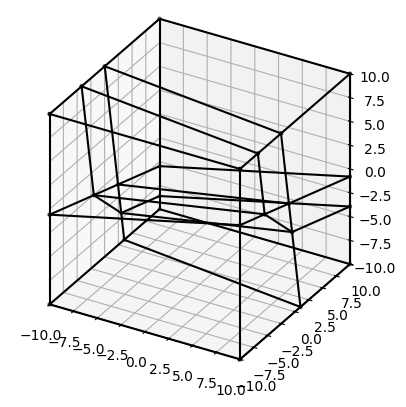

In [5]:
### Define a NN ###
torch.manual_seed(12); f = Net(ks=[3,2,1]); bbox = -10, 10 ## running example
# f = NetBunny(dim=3, depth=3, width=16); bbox = -.5, .5
B = 2*f.ks[0] ## number of hyperplanes defining the domain is 2*input_dim. This holds just for the hyperrectangle

### Run subdivision ###
with torch.no_grad():
    # torch.rand(1, device='cuda') ## intialize cuda context, if you want to do automated timings
    # vs, edges, v_sv = skeletal_subdivision(f, device='cuda', plot=0, prune=0, bbox=bbox)
    vs, edges, v_sv = skeletal_subdivision(f, device='cpu', plot=0, prune=0, bbox=bbox)


### Plot ###
from utils_viz import plot_verts_and_edges
from utils import get_labels
e_sv = get_e_sv(v_sv, edges)
plot_verts_and_edges(vs, edges, verts=1, bbox=bbox)
# plot_verts_and_edges(vs, edges, e_labels=get_labels(e_sv, B=B), verts=False, bbox=bbox)
# plot_verts_and_edges(vs, edges, e_labels=get_labels(e_sv, B=0), v_labels=get_labels(v_sv, B=0), bbox=bbox)
# plot_verts_and_edges(vs, edges, verts=0, edge_colors=np.where(e_sv[:,-1].cpu()==0, 'g', 'k'), bbox=bbox) ## Highlight the iso-edges